### Analysis of learned plasticity rule that organizes integrating network
Networks initialized with structured input weights, but weights in 'ellipsoid body' are random but fully connected.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import glob as glob
import matplotlib
import matplotlib.pyplot as plt
import os
from aux import zero_pad, format_plot, format_pc_plot, add_inset_axes
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn import linear_model
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.offline as pyo
import subprocess
import cv2
from natsort import natsorted
import seaborn as sns

plt.rcParams['font.family'] = 'Helvetica'

DATA_PATHS = [
    'interspersed_no_noise_DC_test_shift_784624_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-08-27_08:43:57.400490_run_None',
    'interspersed_no_noise_DC_test_shift_218460_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-08-27_12:41:21.756043_run_None',
]

DATA_PATHS = [ './sims_out/' + d for d in DATA_PATHS]

In [2]:
def load_numpy(data_path):
    file_names = glob.glob(data_path)
    data = []
    for file_name in sorted(file_names):
        data_for_file = np.load(file_name)
        data.append(data_for_file)
    return data

def make_path_if_not_exists(path_str):
    Path(path_str).mkdir(parents=True, exist_ok=True)

### Analysis of neural activity

In [3]:
def load_r_and_int_values(rule_path, net_path, last_n=100, trim_from_r=200):
    all_r = np.stack(load_numpy(os.path.join(rule_path, 'activities', net_path)))
    all_int_values = np.stack(load_numpy(os.path.join(rule_path, 'integrated_values', net_path)))
    
    if last_n is not None:
        last_n_r = all_r[-last_n:, trim_from_r:, :15]
        all_int_values = all_int_values[-last_n:, :]
    else:
        last_n_r = all_r[:, trim_from_r:, :15]
        
    last_n_r = np.transpose(last_n_r, [2, 0, 1])

    return last_n_r, all_int_values

Do PCA on last 50 trials, 15 units in ellipsoid body.

In [4]:
def fit_pca(last_100_r):
    flattened_data = last_100_r.reshape(last_100_r.shape[0], last_100_r.shape[1] * last_100_r.shape[2], order='C')
    pca = PCA()
    pc_activities = pca.fit_transform(flattened_data.T)
    pc_activities = pc_activities.T.reshape(last_100_r.shape, order='C')

    return pc_activities, pca

Learned structure leads to low dimensional activity.

Retrieve target integrated sums. Keep only the last 100 trials.

In [12]:
def make_tuning_curves(last_100_r, all_int_values, save_name_1=None, save_name_2=None):
    ending_states = np.empty((last_100_r.shape[0], last_100_r.shape[1]))
    int_values_for_ending_states = np.empty((all_int_values.shape[0]))
    for i, j in enumerate(np.argsort(all_int_values[:, -50])):
        ending_states[:, i] = last_100_r[:, j, -50]
        int_values_for_ending_states[i] = all_int_values[j, -50]
    
    scale = 2
    fig, axs = plt.subplots(1, 1, figsize=(2 * scale, 2 * scale))
    m = np.abs(ending_states).max()
    axs.matshow(ending_states, cmap='bwr', vmin=-m, vmax=m, aspect=4)
    
    format_plot(axs, rightspine=True, topspine=True)
    
    axs.set_xlabel('Integrated sum', fontsize=16)
    axs.set_xticks([0, 100], ['Leftmost', 'Rightmost'])
    axs.set_ylabel('Neuron', fontsize=16)
    axs.set_yticks([0, 14])
    axs.tick_params(axis='both', length=6, labelsize=16)

    if save_name_1 is not None:
        fig.savefig(save_name_1, bbox_inches='tight')
    
    scale = 2
    fig, axs = plt.subplots(1, 1, figsize=(2.3 * scale, 1.3 * scale))
    
    cmap = sns.diverging_palette(145, 300, s=60, as_cmap=True)
    int_min, int_max = int_values_for_ending_states.min(), int_values_for_ending_states.max()
    colors = [cmap((int_values_for_ending_states[i] - int_min) / (int_max - int_min))[:3] for i in range(100)]  # 49 to include 0 and 1
    
    for i in range(ending_states.shape[1]):
        axs.plot(np.arange(ending_states.shape[0]), ending_states[:, i], color=colors[i], lw=1)

    norm = matplotlib.colors.Normalize(vmin=int_min, vmax=int_max)
    sm = matplotlib.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # Only needed for older versions of matplotlib
    cbar = fig.colorbar(sm, ax=axs, orientation='vertical', pad=0.02)
    cbar.set_label("Integrated value")
    format_plot(cbar.ax)
    
    format_plot(axs)
    
    axs.set_ylabel('Firing rate (Hz)', fontsize=16)
    axs.set_xlabel('Neuron', fontsize=16)
    axs.set_xticks([0, 14])
    axs.set_xlim(0, 14)
    axs.tick_params(axis='both', length=6, labelsize=16)

    if save_name_2 is not None:
        fig.savefig(save_name_2, bbox_inches='tight')

In [13]:
from matplotlib import gridspec

def make_stability_plot(last_100_r, all_int_values, save_name=None):
    
    cmap = sns.diverging_palette(145, 300, s=60, as_cmap=True)
    scale = 3

    if all_int_values.shape[-1] < last_100_r.shape[-1]:
        all_int_values = np.concatenate([
            all_int_values,
            all_int_values[:,-1:] * np.ones((all_int_values.shape[0], last_100_r.shape[-1] - all_int_values.shape[-1])),
        ], axis=1)

    def normed_loc(raster):
        total_activity = raster.sum(axis=0)
        raster_normed = np.divide(
            raster,
            total_activity[None, ...],
            where=total_activity != 0,
            out=np.zeros_like(raster)
        )
        ordered_indices = np.argsort(raster, axis=0)
        max_5_indices = ordered_indices[-13:, :]
        x = np.arange(raster_normed.shape[0])
        cols = np.arange(raster.shape[1])[None, :]
        locs = np.einsum(
            'ij,ij->j',
            x[max_5_indices],
            raster_normed[max_5_indices, cols],
        )
        return locs

    all_final_traj = []

    # Create a figure with 2 columns: main plot and histogram
    fig = plt.figure(figsize=(2.5 * scale, 1 * scale))
    gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1], wspace=0.05)
    ax_main = fig.add_subplot(gs[0])
    ax_hist = fig.add_subplot(gs[1], sharey=ax_main)

    sorted_int_values = []

    # Use global color normalization for consistent coloring
    global_max = np.max(np.abs(all_int_values))
    norm = matplotlib.colors.Normalize(vmin=-global_max, vmax=global_max)

    for i, j in enumerate(np.argsort(all_int_values[:, -50])): # corresponding to 50 ms lag
        traj = normed_loc(last_100_r[:, j, :])
        all_final_traj.append(traj[-1])
        cbar = ax_main.plot(
            np.arange(all_int_values.shape[1]),
            traj,
            alpha=0.5,
            color=cmap(norm(all_int_values[j, -1])),
        )
        
        sorted_int_values.append(all_int_values[j, :])

    # Main plot formatting
    ax_main.set_xlabel('Time (ms)', fontsize=16)
    ax_main.set_ylabel('Bump location', fontsize=16)
    ax_main.set_xticks(np.arange(0, 1301, 1000))
    ax_main.set_xticklabels((np.arange(0, 1301, 1000) / 10).astype(int))
    ax_main.set_yticks([0, 15], [0, 15])
    ax_main.set_ylim(-1, 16)
    ax_main.set_xlim(0)
    ax_main.tick_params(axis='both', length=6, labelsize=14)
    format_plot(ax_main, ticklabelsize=16, axislabelsize=16)

    # Histogram on the right (rotated)
    ax_hist.hist(all_final_traj, bins=30, orientation='horizontal', color='gray')
    ax_hist.set_xlabel('Count', fontsize=16)
    ax_hist.tick_params(axis='x', labelsize=14)
    ax_hist.tick_params(axis='y', labelleft=False)  # Hide y-axis labels to avoid duplication
    format_plot(ax_hist, ticklabelsize=16, axislabelsize=16)

    if save_name is not None:
        fig.savefig(save_name, bbox_inches='tight')

    plt.show()

    fig, axs = plt.subplots(1, 1, figsize=(1 * scale, 1 * scale))

    # axs.plot([-m, m], [-m, m], color='black', zorder=0)
    axs.scatter(np.stack(sorted_int_values)[:, -1], all_final_traj, s=30, zorder=1, facecolor='red', edgecolor='red', alpha=0.2)
    # axs.set_xlim(-m, m)
    # axs.set_ylim(-m, m)
    # axs.set_xticks([-100, 0, 100])
    # axs.set_yticks([-100, 0, 100])
    
    format_plot(axs)

    axs.set_xlabel(r'$y$', fontsize=16)
    axs.set_ylabel(r'Bump location', fontsize=16)
    # axs.set_title('Predicted vs true integrated sums', fontsize=16)
    axs.tick_params(axis='both', length=6, labelsize=16)
    

Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


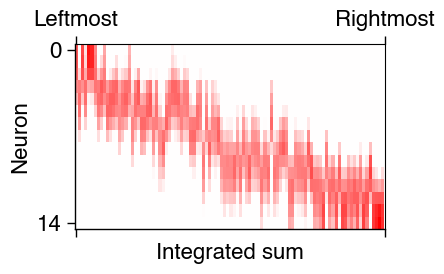

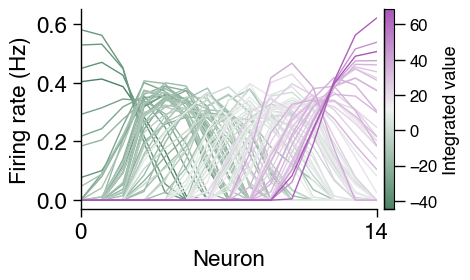

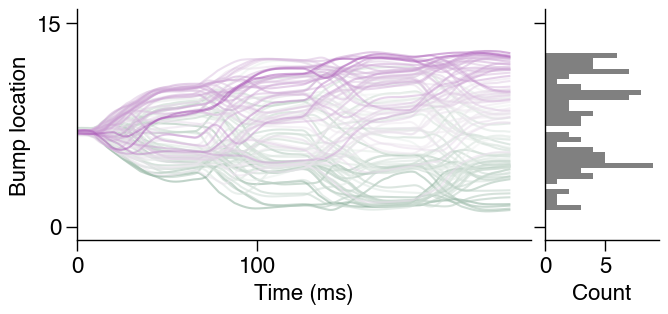

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


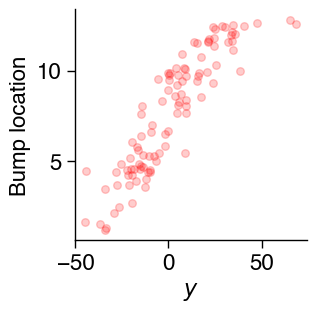

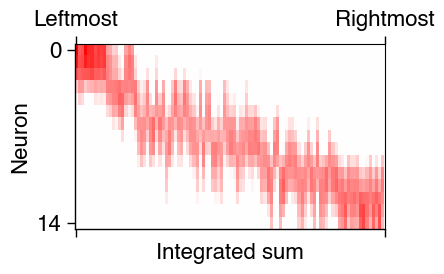

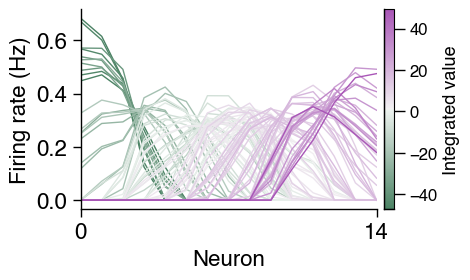

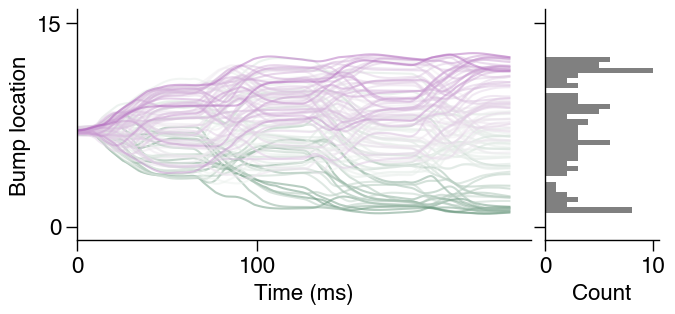

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


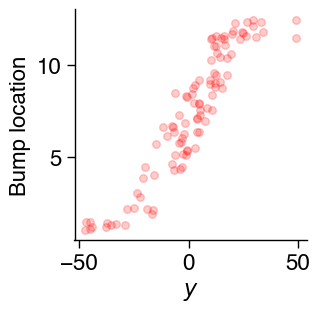

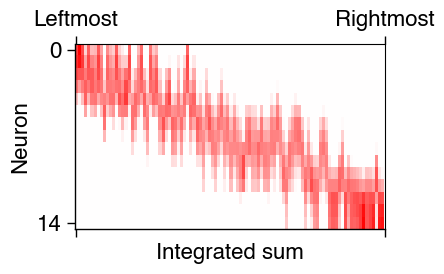

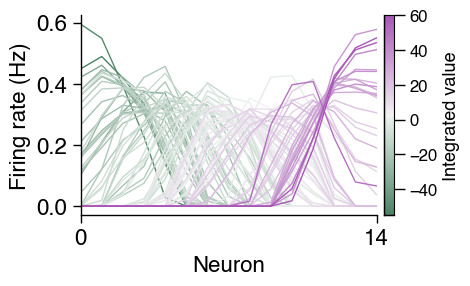

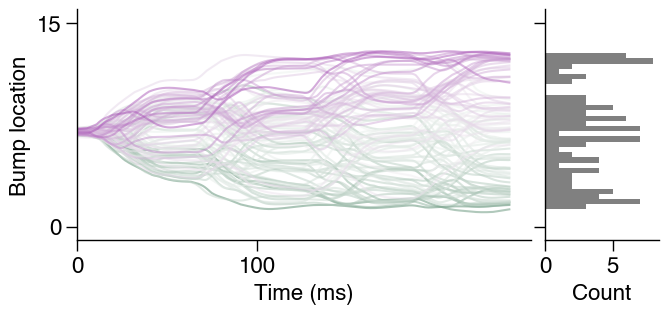

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


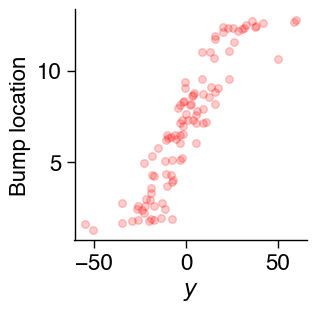

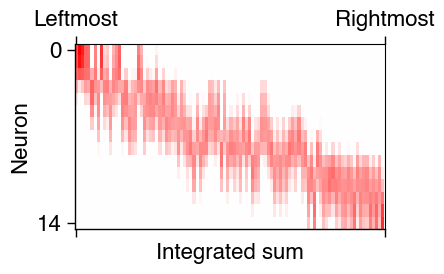

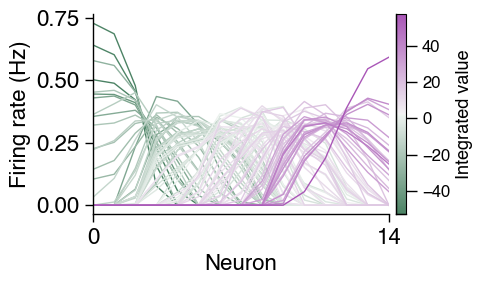

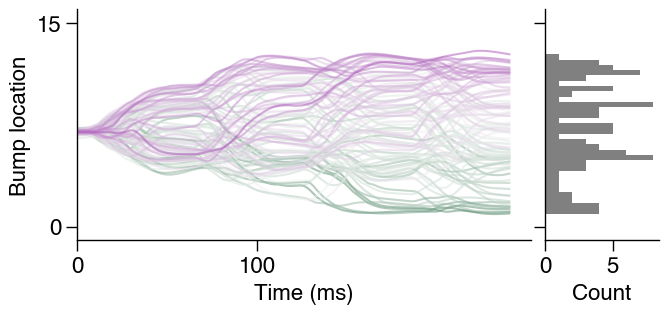

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


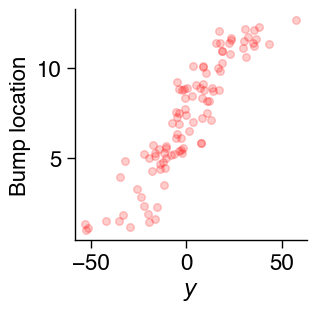

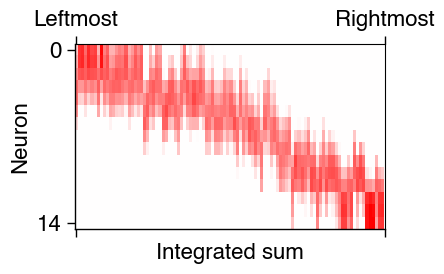

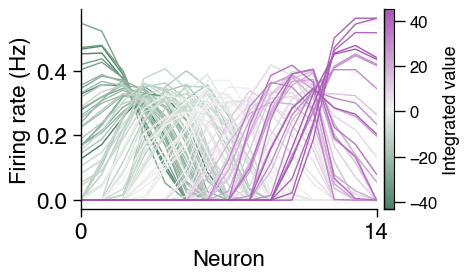

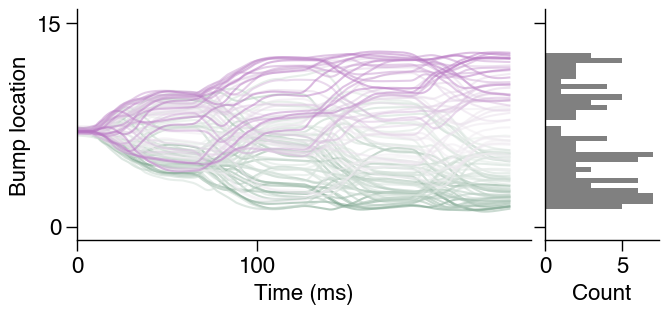

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


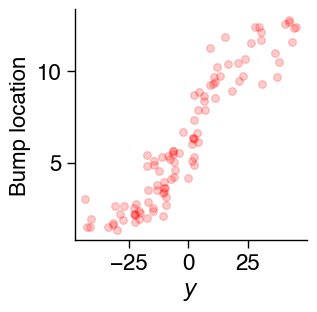

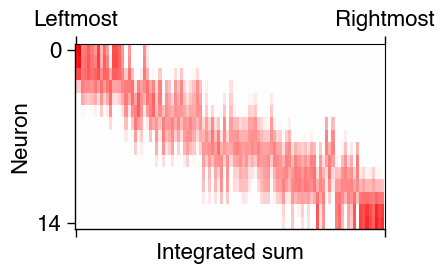

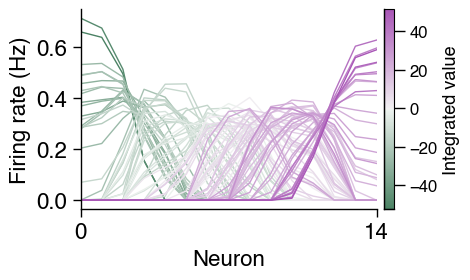

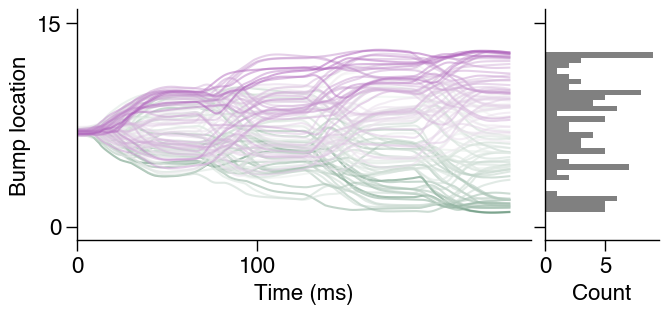

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


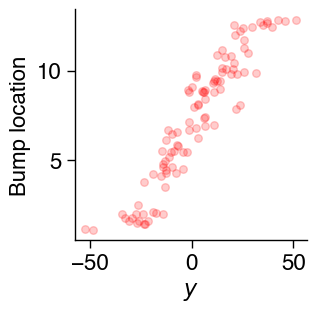

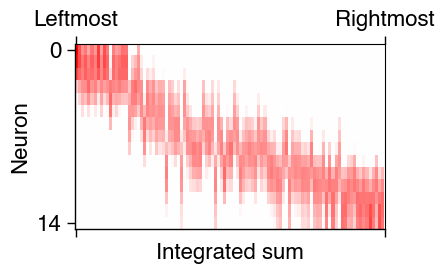

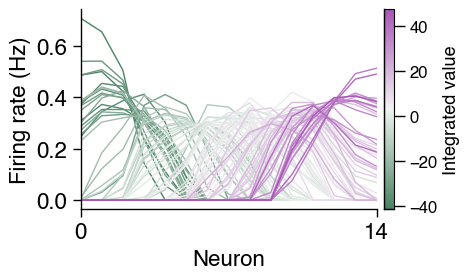

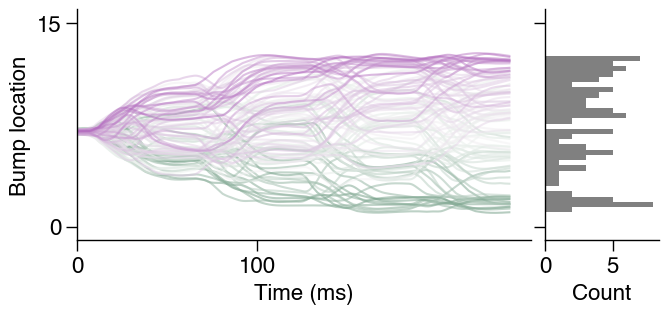

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


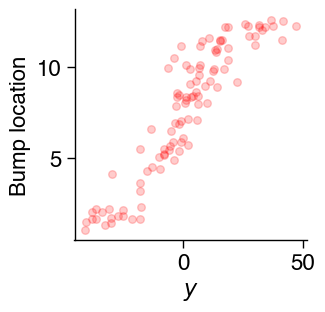

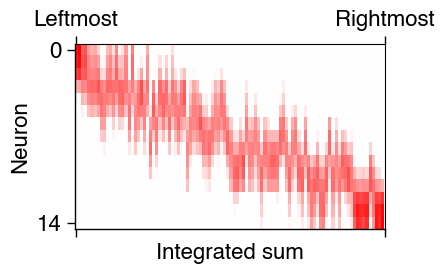

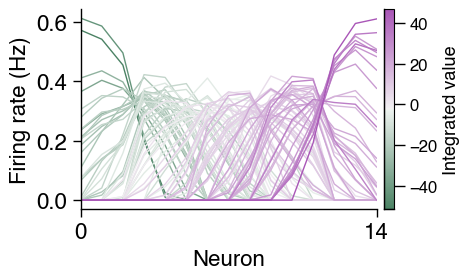

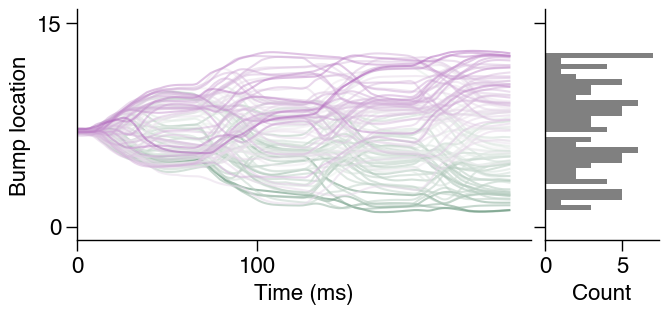

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


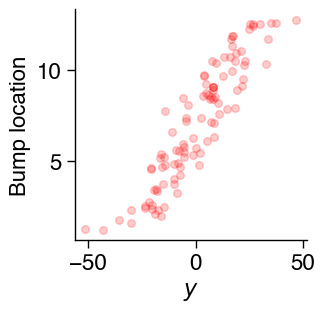

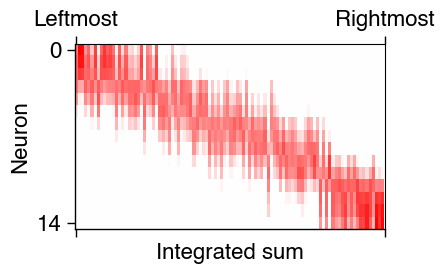

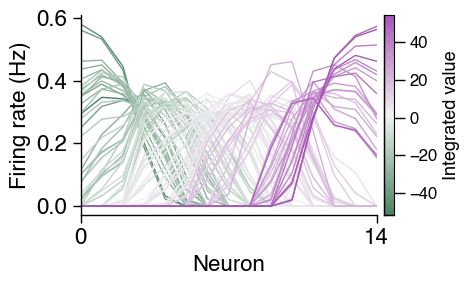

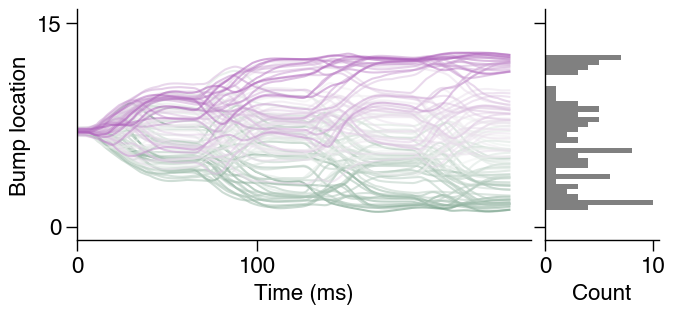

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


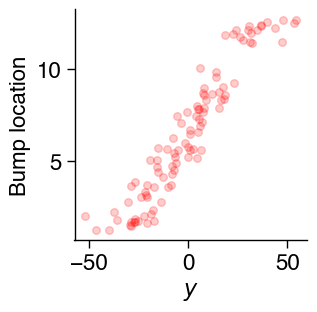

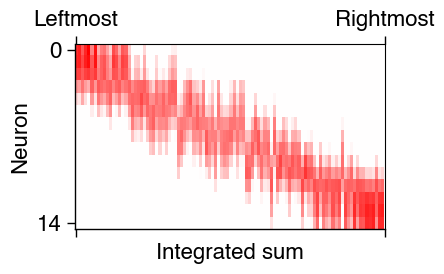

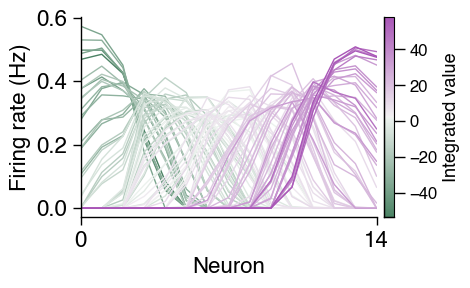

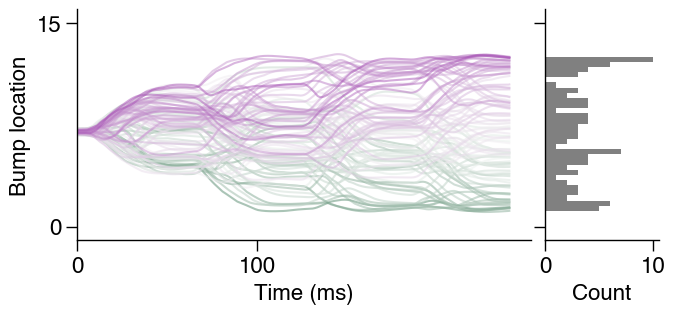

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


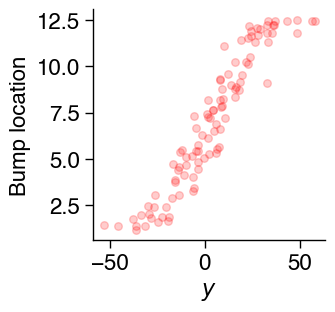

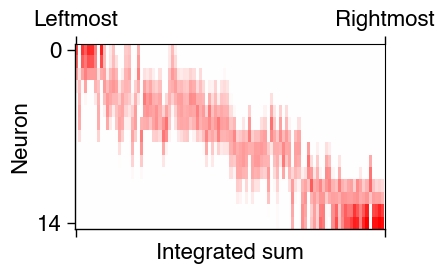

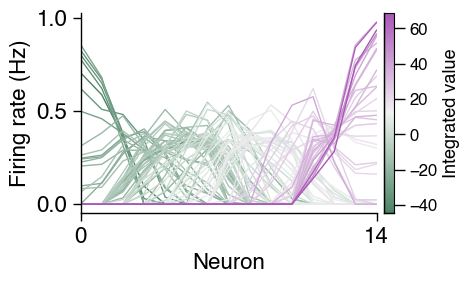

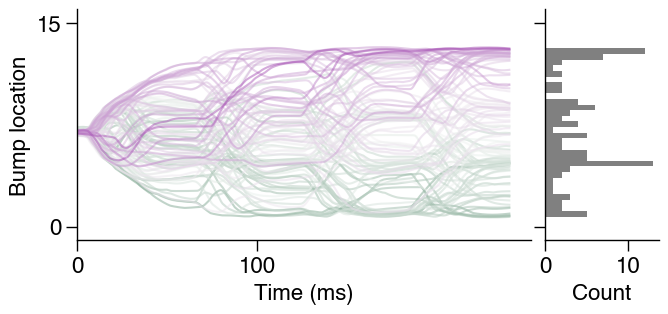

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


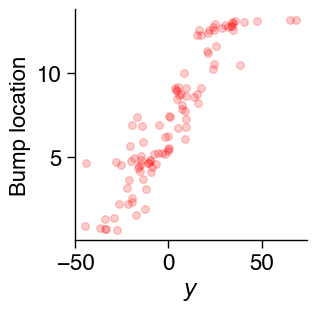

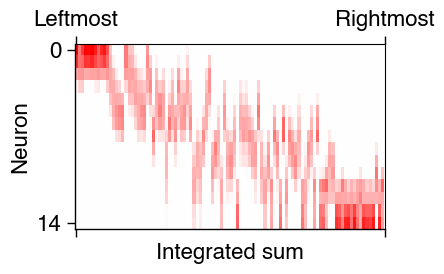

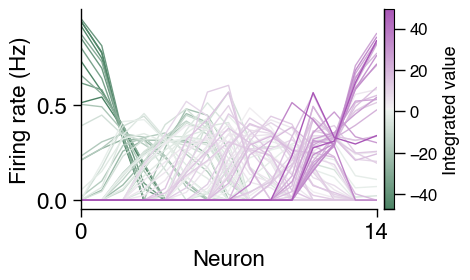

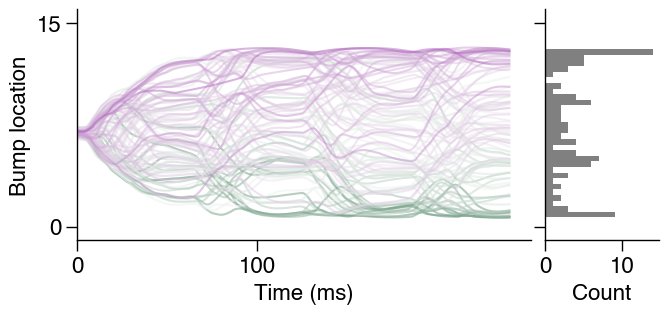

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


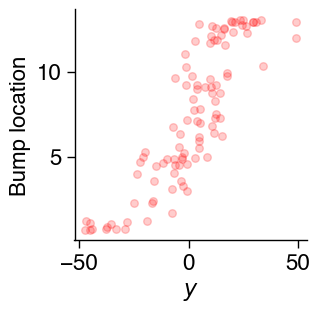

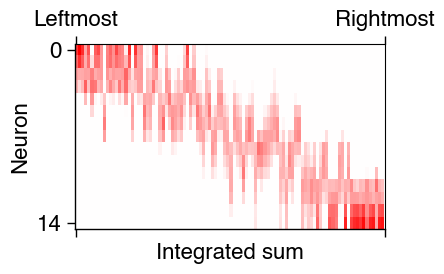

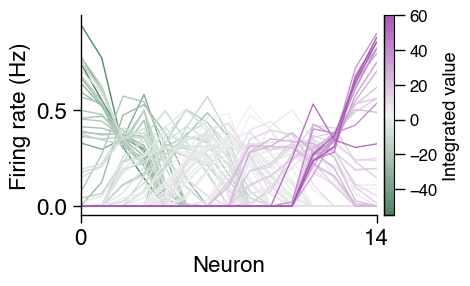

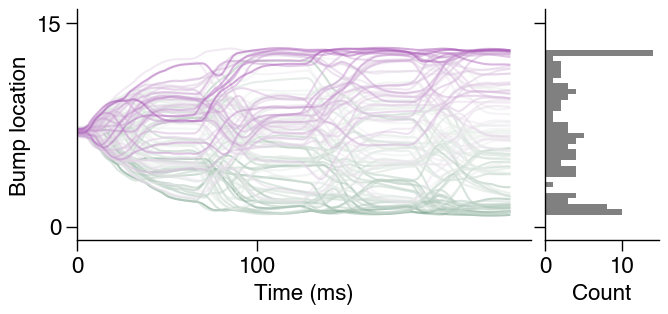

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


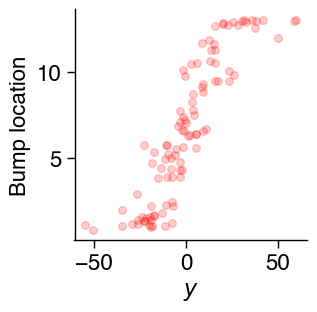

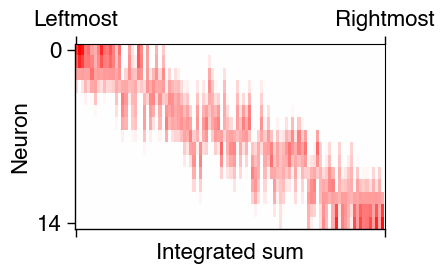

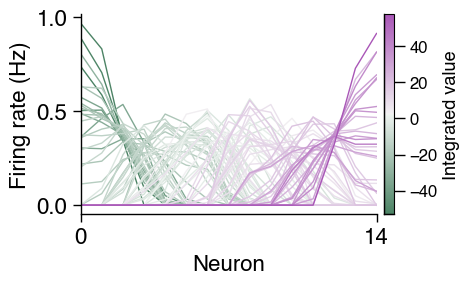

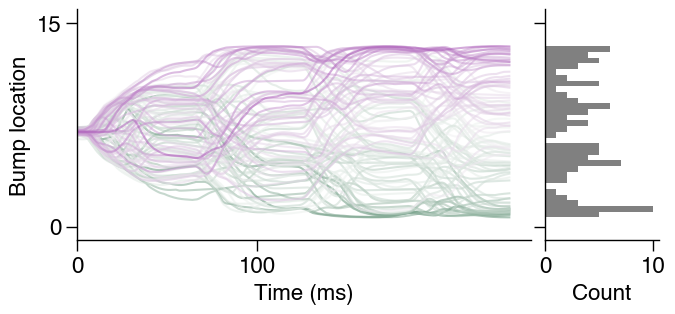

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


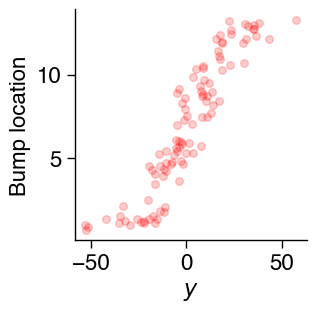

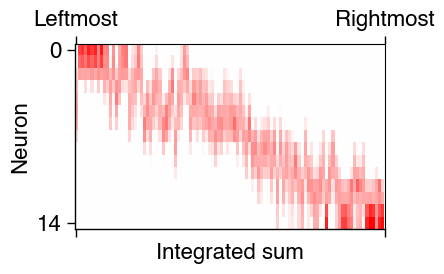

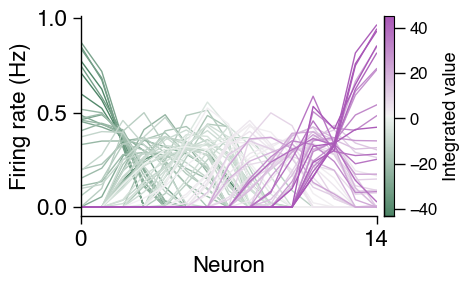

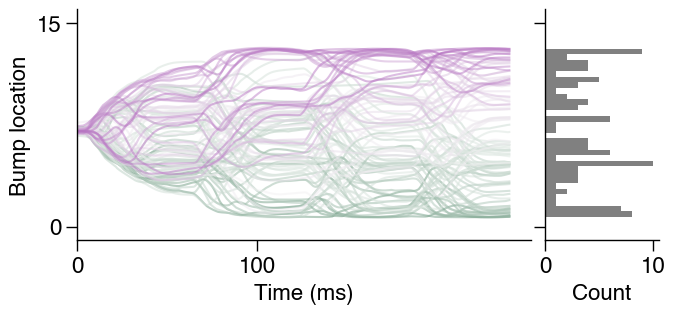

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


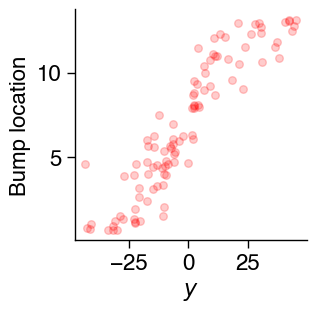

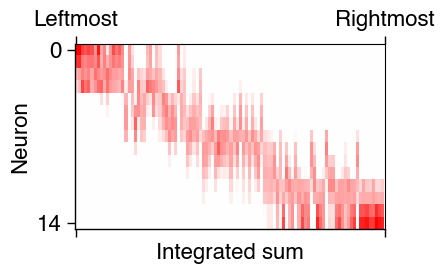

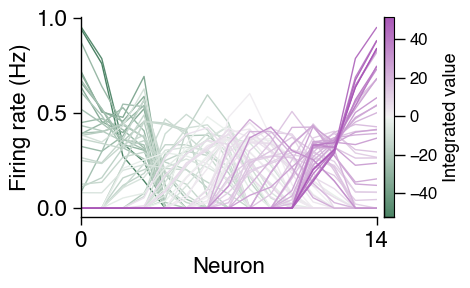

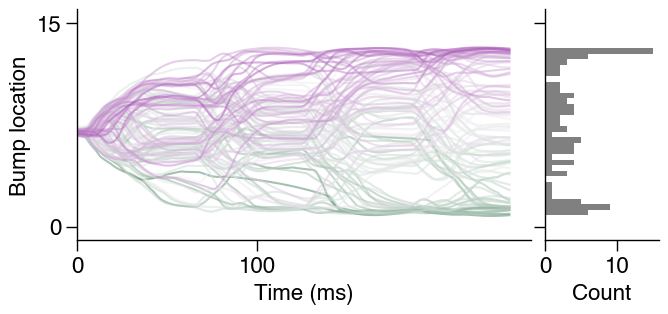

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


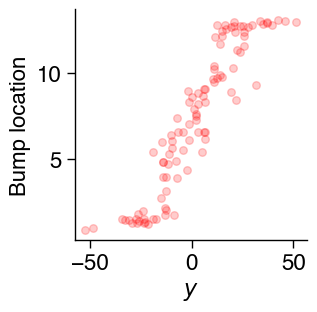

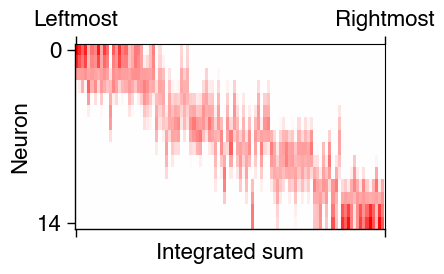

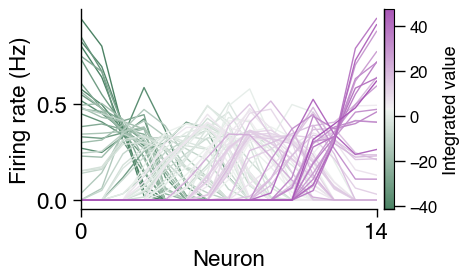

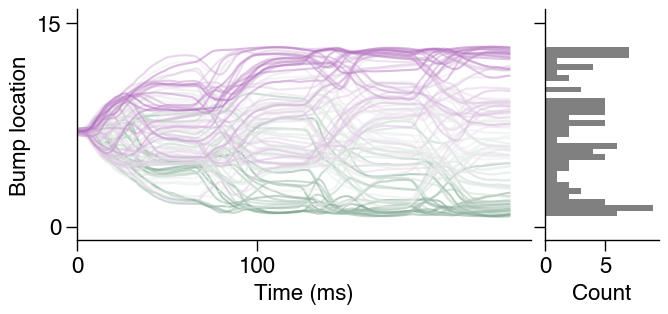

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


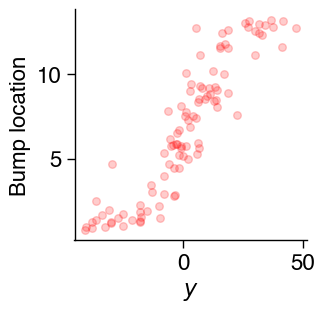

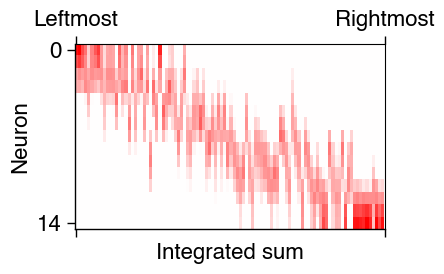

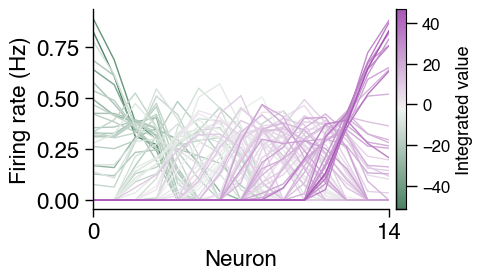

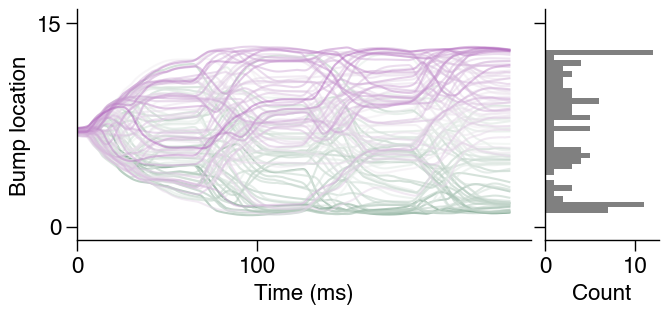

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


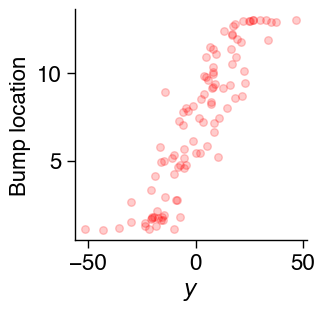

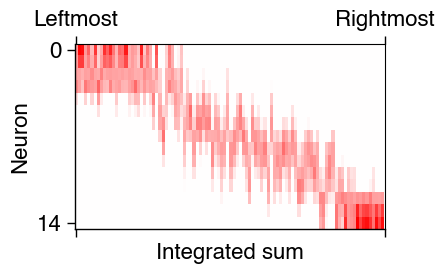

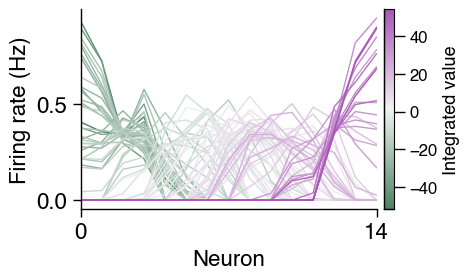

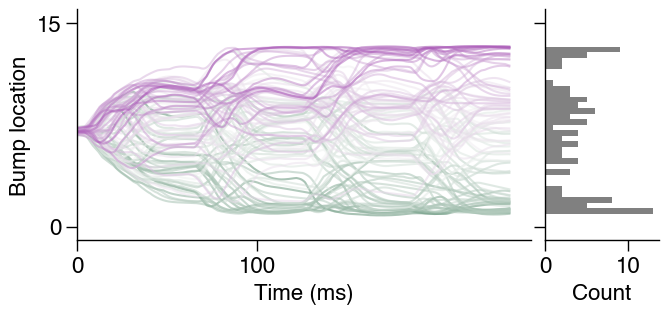

Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)
Axes(0.78375,0.11;0.11625x0.77)
Axes(0.125,0.11;0.64325x0.77)
Axes(0.125,0.11;0.604878x0.77)
Axes(0.74878,0.11;0.15122x0.77)


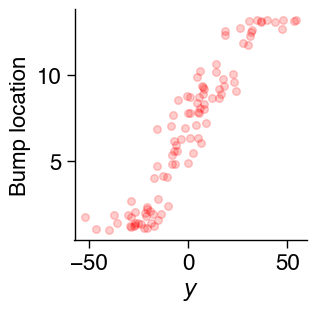

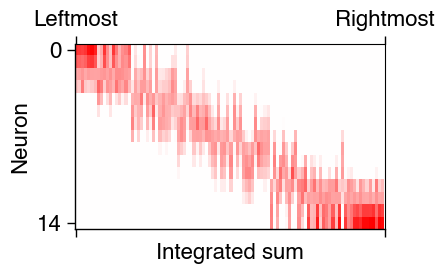

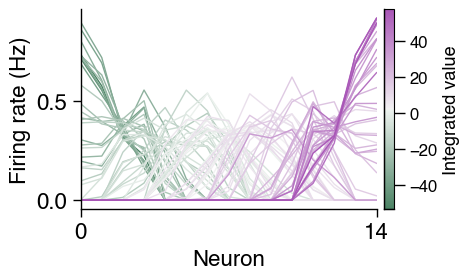

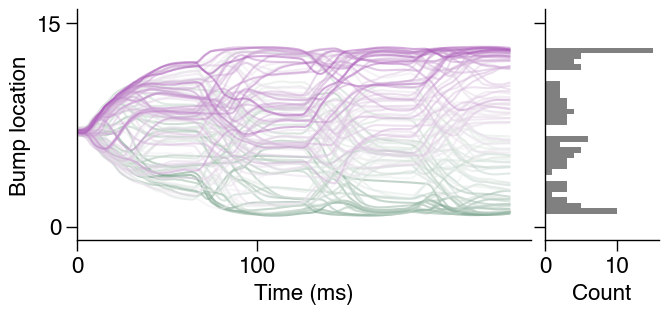

Axes(0.125,0.11;0.775x0.77)


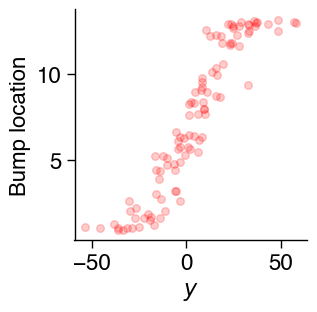

In [14]:
for dp in DATA_PATHS:
    for i in range(10):
        last_100_r, all_int_values = load_r_and_int_values(dp, f'net_00{i}_*.npy', last_n=100)
        make_tuning_curves(
            last_100_r,
            all_int_values,
            save_name_1=f'./figures/ordered_states_{i}.svg',
            save_name_2=f'./figures/tuning_curve_{i}.svg',
        )
        make_stability_plot(last_100_r, all_int_values, save_name=f'./figures/stability_plot_{i}.svg')

In [ ]:
from scipy.stats import gaussian_kde

def test_representation_fidelity(all_r, all_int_values, n_fold=20, lasso_alpha=0.1):

    self_org_iters = 280
    train_range = slice(self_org_iters, self_org_iters + 40)
    test_range = slice(self_org_iters + 40, self_org_iters + 140)
    
    stacked_activities_train = all_r[:, train_range, :]
    y_train = all_int_values[train_range, :]
    stacked_activities_test = all_r[:, test_range, :]
    y_test = all_int_values[test_range, :]
    
    scores = []
    
    for i in range(n_fold):
        train_acts = np.random.randint(0, 40, size=8000)
        train_steps = np.random.randint(0, 2250, size=8000)
        test_acts = np.arange(100)
        test_steps = np.random.randint(0, 2250, size=100)
        
        X_train = stacked_activities_train[:, train_acts, train_steps + 50].T # add 5 ms lag between inputs and decoded value
        Y_train = y_train[train_acts, train_steps]

        kde = gaussian_kde(Y_train)
        
        X_test = stacked_activities_test[:, test_acts, test_steps + 50].T # add 5 ms lag between inputs and decoded value
        Y_test = y_test[test_acts, test_steps]
        
        reg = linear_model.Lasso(alpha=lasso_alpha).fit(X_train, Y_train, sample_weight=1 / kde(Y_train))
        score = reg.score(X_test, Y_test)
        scores.append(score)
    
    print(scores)
    print(np.mean(scores))

    scale = 0.8
    fig, axs = plt.subplots(1, 1, figsize=(4 * scale, 4 * scale))

    Y_hat = reg.predict(X_test)

    m = 1.05 * np.max(np.abs(np.concatenate([Y_test, Y_hat])))
    
    axs.plot([-m, m], [-m, m], color='black', zorder=0)
    axs.scatter(Y_test, Y_hat, s=30, zorder=1, facecolor='none', edgecolor='red', alpha=0.5)
    axs.set_xlim(-m, m)
    axs.set_ylim(-m, m)
    axs.set_xticks([-100, 0, 100])
    axs.set_yticks([-100, 0, 100])
    
    format_plot(axs)
    
    axs.set_xlabel(r'$y$', fontsize=16)
    axs.set_ylabel(r'$\hat{y}$', fontsize=16)
    axs.set_title('Predicted vs true integrated sums', fontsize=16)
    axs.tick_params(axis='both', length=6, labelsize=16)

    return np.mean(scores)

[0.8441608639394851, 0.8529496333263764, 0.8738681804677326, 0.8564528214723343, 0.8231872557438289]
0.8501237509899514
Axes(0.125,0.11;0.775x0.77)
[0.8986606888088813, 0.8959286485532829, 0.8644844238072313, 0.8583131327731178, 0.878080548045968]
0.8790934883976963
Axes(0.125,0.11;0.775x0.77)
[0.7840212122855247, 0.8094138036343985, 0.7460468544377323, 0.7781714922378913, 0.8318591817221984]
0.789902508863549
Axes(0.125,0.11;0.775x0.77)
[0.848304576334758, 0.8786107016455744, 0.857230409588399, 0.8269589138591225, 0.8363743447947231]
0.8494957892445154
Axes(0.125,0.11;0.775x0.77)
[0.7626919902185052, 0.8414662572076769, 0.8545753428450976, 0.8435247035564424, 0.8413525974269502]
0.8287221782509345
Axes(0.125,0.11;0.775x0.77)
[0.8659858516228607, 0.8481248399036431, 0.8732219680802545, 0.8823571196121549, 0.8558768627069605]
0.8651133283851747
Axes(0.125,0.11;0.775x0.77)
[0.8417027728187836, 0.8891251213619248, 0.8246678098325708, 0.80408149424676, 0.8716434756771498]
0.846244134787437

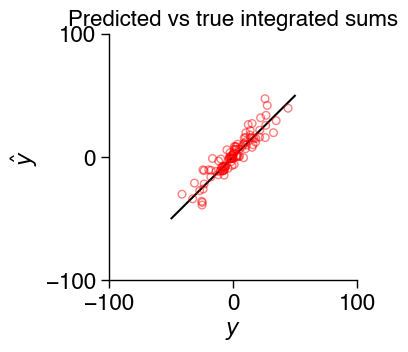

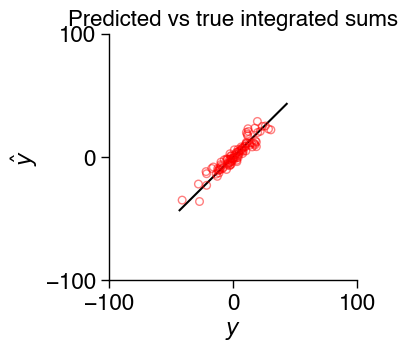

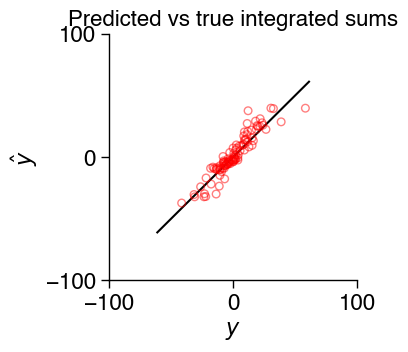

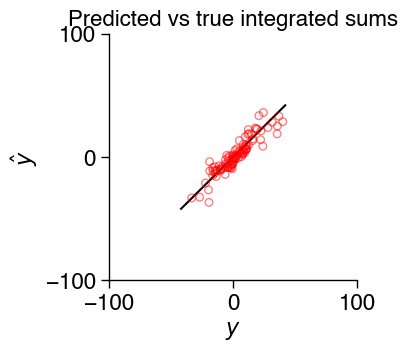

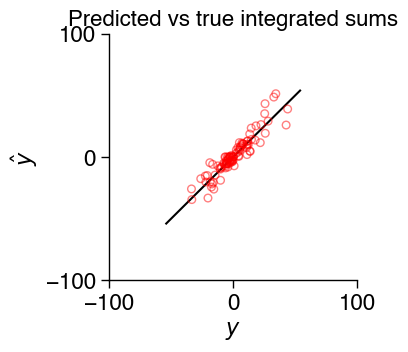

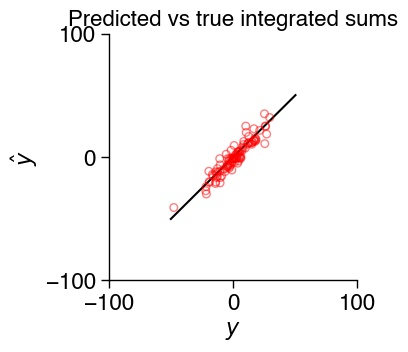

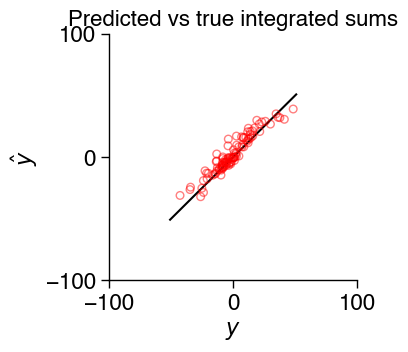

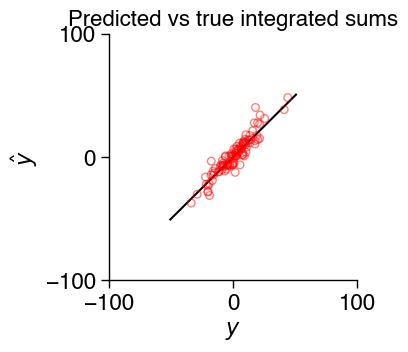

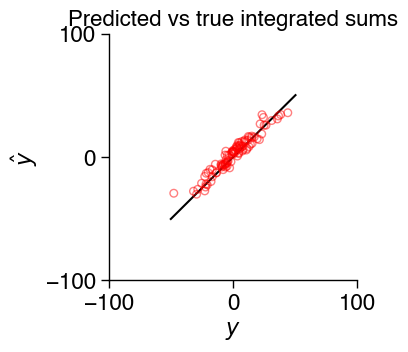

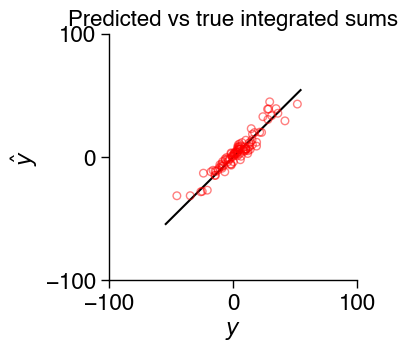

In [22]:
all_scores = []
for dp in DATA_PATHS[:1]:
    for i in range(10):
        all_r, all_int_values = load_r_and_int_values(dp, f'net_00{i}_*.npy', last_n=None)
        score = test_representation_fidelity(all_r, all_int_values, n_fold=5)
        all_scores.append(score)

In [26]:
np.mean(all_scores)

np.float64(0.8512337510459002)

In [27]:
all_scores_hard_coded = np.load('preprocessing/hard_coded_r2_scores_inh_het.npy')

Axes(0.125,0.11;0.775x0.77)


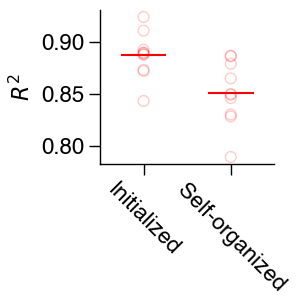

In [43]:
fig, axs = plt.subplots(1, 1, figsize=(2.25, 2))

scores = np.stack([all_scores_hard_coded[0, :], all_scores]) 

for k in range(scores.shape[0]):
    x_scatter = np.ones(scores.shape[1]) * k
    axs.scatter(x_scatter, scores[k, :],
                facecolor='none', edgecolor='red', s=60, alpha=0.2)

    mean_line_width = 0.25
    axs.plot([k - mean_line_width, k + mean_line_width], np.mean(scores[k, :]) * np.ones(2), c='red', lw=1.5)
    
    
    # Add boxplot shifted slightly to the right
    # axs.boxplot(all_scores_cp[k, :],
    #             positions=[k + offset],
    #             widths=0.25,
    #             patch_artist=True,
    #             boxprops=dict(facecolor='white', color='black'),
    #             medianprops=dict(color='black'),
    #             whiskerprops=dict(color='black'),
    #             capprops=dict(color='black'),
    #             flierprops=dict(marker='o', color='black', alpha=0.3))

# axs.set_yticks(np.arange(5) * 0.25, np.arange(5) * 0.25)
axs.set_xticks(np.arange(2), ['Initialized', 'Self-organized'], rotation=-45)
# axs.set_ylim(0, 1)
axs.set_xlim(-0.5, 1.5)

axs.set_ylabel(r'$R^2$')

format_plot(axs, ticklabelsize=16, axislabelsize=16)


# fig.savefig('figures/hard_coded_accuracy_versus_inh_het.svg')
# fig.savefig('figures/hard_coded_accuracy_versus_inh_het.png')

In [ ]:
all_scores = []
for dp in DATA_PATHS[1:]:
    for i in range(10):
        all_r, all_int_values = load_r_and_int_values(dp, f'net_00{i}_*.npy', last_n=None)
        score = test_representation_fidelity(all_r, all_int_values, n_fold=5)
        all_scores.append(score)